In [66]:
import warnings
import sys
sys.path.append(r'work/util.py')
from util import *
warnings.filterwarnings("ignore")
random.seed(42)



from warnings import filterwarnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import TunedThresholdClassifierCV  # This import may not exist, but leaving as is for now
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score, make_scorer, accuracy_score, precision_score, recall_score, auc
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from category_encoders import TargetEncoder
from category_encoders.woe import WOEEncoder
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_classif
from sklearn.metrics import make_scorer, fbeta_score
import numpy as np
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, fbeta_score
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
import pickle

filterwarnings('ignore')



In [67]:
def configure_spark():

    spark = (
        SparkSession.builder
        .appName("lakehouse-jupyter-abt")

        # conexão com cluster
        .master(os.getenv("SPARK_MASTER"))

        # 🚨 ESSENCIAL em Docker
        .config("spark.driver.host", os.getenv("SPARK_DRIVER_HOST"))
        .config("spark.driver.bindAddress", "0.0.0.0")

        # Delta Lake
        .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
        .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

        # S3 / MinIO
        .config("spark.hadoop.fs.s3a.endpoint", os.getenv("MINIO_ENDPOINT"))
        .config("spark.hadoop.fs.s3a.path.style.access", "true")
        .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")

        .config("spark.hadoop.fs.s3a.access.key", os.getenv("AWS_ACCESS_KEY_ID"))
        .config("spark.hadoop.fs.s3a.secret.key", os.getenv("AWS_SECRET_ACCESS_KEY"))

        .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        .config(
            "spark.hadoop.fs.s3a.aws.credentials.provider",
            "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider"
        )

        # performance
        .config("spark.sql.adaptive.enabled", "true")

        # Delta fix
        .config("spark.databricks.delta.retentionDurationCheck.enabled", "false")

        .getOrCreate()
    )

    spark.sparkContext.setLogLevel("WARN")

    return spark

In [68]:
spark = configure_spark()
spark

In [79]:
abt_treino_00 = spark.read.table("delta.`s3a://gold/abt_treino`")
abt_teste_00 = (
    spark.read.table("delta.`s3a://gold/abt_teste`")
    .filter(col("safra").isin(201805, 201806))
)

In [80]:
abt_treino = abt_treino_00.toPandas()

In [81]:
abt_teste = abt_teste_00.toPandas()

In [82]:
abt_treino = abt_treino.copy()
abt_treino_01 = abt_treino.drop(columns=[])
abt_treino_01.head()

,seller_id,safra,flag_sem_venda_2m,seller_region,vl_med_u1m_price_orders,vl_max_u1m_price_orders,vl_min_u1m_price_orders,vl_std_u1m_price_orders,vl_qtd_u1m_price_orders,vl_med_u1m_freight_value_orders,...,vl_qtd_u9m_review_score_reviews,vl_med_u12m_review_score_reviews,vl_max_u12m_review_score_reviews,vl_min_u12m_review_score_reviews,vl_std_u12m_review_score_reviews,vl_qtd_u12m_review_score_reviews,raz_med_u1m_u3m_review_score_reviews,raz_med_u3m_u6m_review_score_reviews,raz_med_u6m_u9m_review_score_reviews,raz_med_u9m_u12m_review_score_reviews
0,ff063b022a9a0aab91bad2c9088760b7,201804,0,SUDESTE,102.26,154.00,93.00,18.46,19,18.11,...,49.0,4.22,5.0,1.0,1.10,51.0,0.980676,0.976415,1.000000,1.004739
1,0ea22c1cfbdc755f86b9b54b39c16043,201804,0,SUDESTE,34.44,40.00,25.00,5.11,18,17.17,...,104.0,4.44,5.0,1.0,0.99,165.0,0.972103,1.047191,0.993304,1.009009
2,a49928bcdf77c55c6d6e05e09a9b4ca5,201804,0,SUDESTE,63.00,90.00,19.00,38.43,3,13.67,...,90.0,3.02,5.0,1.0,1.67,92.0,0.604278,0.651568,0.963087,0.986755
3,c522be04e020c1e7b79f3acff36513d5,201804,0,SUDESTE,80.00,80.00,80.00,NaN,1,8.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,da7039f29f90ce5b4846ffc0fcc93beb,201804,0,SUDESTE,50.00,50.00,50.00,NaN,1,15.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
abt_teste = abt_teste.copy()
abt_teste_01 = abt_teste.drop(columns=[])
abt_teste_01.head()

,seller_id,safra,flag_sem_venda_2m,seller_region,vl_med_u1m_price_orders,vl_max_u1m_price_orders,vl_min_u1m_price_orders,vl_std_u1m_price_orders,vl_qtd_u1m_price_orders,vl_med_u1m_freight_value_orders,...,vl_qtd_u9m_review_score_reviews,vl_med_u12m_review_score_reviews,vl_max_u12m_review_score_reviews,vl_min_u12m_review_score_reviews,vl_std_u12m_review_score_reviews,vl_qtd_u12m_review_score_reviews,raz_med_u1m_u3m_review_score_reviews,raz_med_u3m_u6m_review_score_reviews,raz_med_u6m_u9m_review_score_reviews,raz_med_u9m_u12m_review_score_reviews
0,ff063b022a9a0aab91bad2c9088760b7,201806,0,SUDESTE,95.10,119.00,74.00,9.36,20,21.50,...,66.0,4.34,5.0,1.0,1.03,70.0,1.050808,1.002315,0.993103,1.002304
1,e63e8bfa530fb16910dd6956e592bb81,201806,0,SUDESTE,29.00,29.00,29.00,0.00,3,9.33,...,30.0,4.16,5.0,1.0,1.37,31.0,0.926829,0.953488,1.041162,0.992788
2,9803a40e82e45418ab7fb84091af5231,201806,0,CENTRO_OESTE,82.17,125.00,28.00,46.37,6,35.00,...,3.0,2.33,5.0,1.0,2.31,3.0,1.000000,1.000000,1.000000,1.000000
3,c522be04e020c1e7b79f3acff36513d5,201806,0,SUDESTE,116.67,140.00,70.00,40.41,3,18.67,...,3.0,4.67,5.0,4.0,0.58,3.0,1.000000,1.000000,1.000000,1.000000
4,0ea22c1cfbdc755f86b9b54b39c16043,201806,0,SUDESTE,36.92,80.00,20.00,14.80,13,16.85,...,98.0,4.46,5.0,1.0,1.02,140.0,1.021692,1.019912,1.011186,1.002242


In [84]:

# Calcular a média do FPD e o volume por AAAAMM
resultado = abt_treino_01.groupby('safra').agg({'flag_sem_venda_2m': 'mean', 'safra': 'count'}).rename(columns={'safra': 'Volume'}).reset_index()
resultado.columns = ['Safra (AAAA)', 'Taxa_de_Evento', 'Volume']

# Exiba a tabela
resultado

,Safra (AAAA),Taxa_de_Evento,Volume
0,201709,0.139633,709
1,201710,0.141534,756
2,201711,0.173679,927
3,201712,0.166074,843
4,201801,0.166667,948
5,201802,0.145788,926
6,201803,0.154555,977
7,201804,0.166819,1097


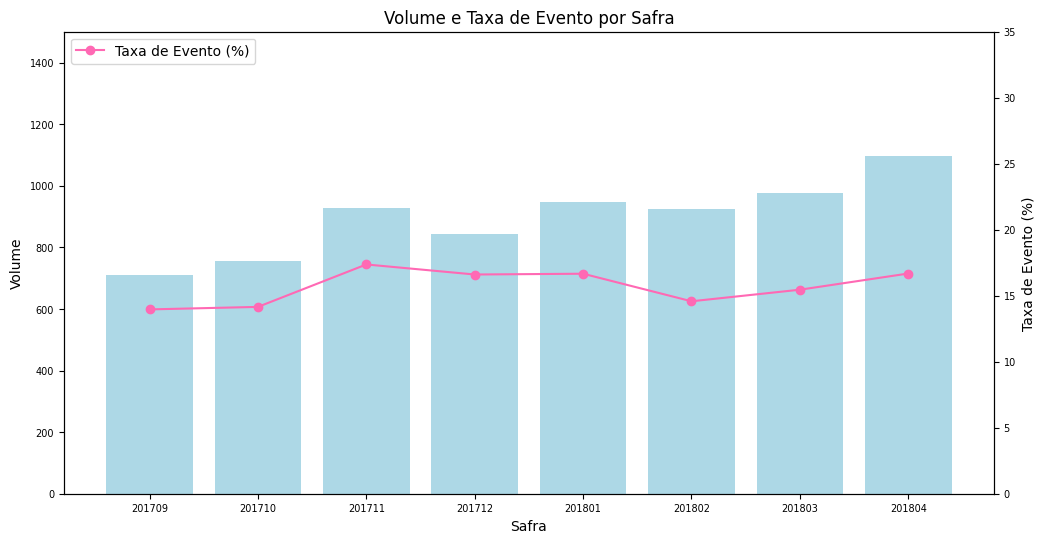

In [85]:

df_tx_evento = plot_tx_event_volume_safra(abt_treino_01,
                                              target='flag_sem_venda_2m',
                                              safra='safra',
                                              ymax_volume=1500, ymax_taxa_evento=35)

In [86]:

# Calcular a média do FPD e o volume por AAAAMM
resultado_teste = abt_teste_01.groupby('safra').agg({'flag_sem_venda_2m': 'mean', 'safra': 'count'}).rename(columns={'safra': 'Volume'}).reset_index()
resultado_teste.columns = ['Safra (AAAA)', 'Taxa_de_Evento', 'Volume']

# Exiba a tabela
resultado_teste

,Safra (AAAA),Taxa_de_Evento,Volume
0,201805,0.168488,1098
1,201806,0.168257,1153


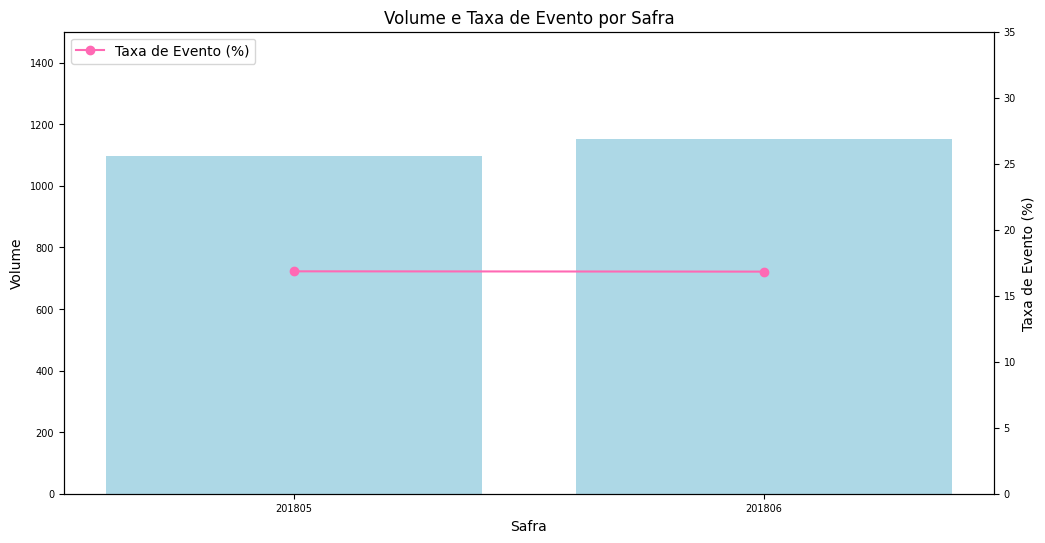

In [87]:

df_tx_evento_teste = plot_tx_event_volume_safra(abt_teste_01,
                                              target='flag_sem_venda_2m',
                                              safra='safra',
                                              ymax_volume=1500, ymax_taxa_evento=35)

In [89]:
metadados = generate_metadata(abt_treino_01, ids=['seller_id', 'safra'], targets=['flag_sem_venda_2m'], orderby='PC_NULOS')
metadados.head(10)

,FEATURE,USO_FEATURE,QT_NULOS,PC_NULOS,CARDINALIDADE,TIPO_FEATURE
0,raz_med_u1m_u3m_fl_atraso_orders,Explicativa,3453,48.07,433,float64
1,raz_med_u3m_u6m_fl_atraso_orders,Explicativa,3137,43.67,356,float64
2,raz_med_u6m_u9m_fl_atraso_orders,Explicativa,2980,41.49,223,float64
3,raz_med_u9m_u12m_fl_atraso_orders,Explicativa,2927,40.75,132,float64
4,vl_std_u1m_review_score_reviews,Explicativa,1860,25.89,186,float64
5,raz_med_u1m_u3m_fl_mesmo_estado_orders,Explicativa,1735,24.15,947,float64
6,vl_std_u3m_review_score_reviews,Explicativa,1596,22.22,191,float64
7,vl_std_u6m_review_score_reviews,Explicativa,1525,21.23,185,float64
8,vl_std_u9m_review_score_reviews,Explicativa,1515,21.09,186,float64
9,vl_std_u12m_review_score_reviews,Explicativa,1511,21.04,186,float64


In [90]:
# Colunas que NÃO entram no modelo
cols_drop = [
    'seller_id',
    'safra',
    'flag_sem_venda_2m'
]

# Treino
X_train = abt_treino_01.drop(columns=cols_drop)
y_train = abt_treino_01['flag_sem_venda_2m']

# Teste
X_test = abt_teste_01.drop(columns=cols_drop)
y_test = abt_teste_01['flag_sem_venda_2m']

In [91]:
metadados = generate_metadata(X_train, ids=['seller_id', 'safra'], targets=['flag_sem_venda_2m'], orderby='PC_NULOS')
metadados.head(10)

,FEATURE,USO_FEATURE,QT_NULOS,PC_NULOS,CARDINALIDADE,TIPO_FEATURE
0,raz_med_u1m_u3m_fl_atraso_orders,Explicativa,3453,48.07,433,float64
1,raz_med_u3m_u6m_fl_atraso_orders,Explicativa,3137,43.67,356,float64
2,raz_med_u6m_u9m_fl_atraso_orders,Explicativa,2980,41.49,223,float64
3,raz_med_u9m_u12m_fl_atraso_orders,Explicativa,2927,40.75,132,float64
4,vl_std_u1m_review_score_reviews,Explicativa,1860,25.89,186,float64
5,raz_med_u1m_u3m_fl_mesmo_estado_orders,Explicativa,1735,24.15,947,float64
6,vl_std_u3m_review_score_reviews,Explicativa,1596,22.22,191,float64
7,vl_std_u6m_review_score_reviews,Explicativa,1525,21.23,185,float64
8,vl_std_u9m_review_score_reviews,Explicativa,1515,21.09,186,float64
9,vl_std_u12m_review_score_reviews,Explicativa,1511,21.04,186,float64


In [92]:
cat_features_low_card = metadados[(metadados['TIPO_FEATURE'] == 'object') & 
                                (metadados['CARDINALIDADE'] < 20)]['FEATURE'].tolist()

cat_features_high_card = metadados[(metadados['TIPO_FEATURE'] == 'object') & 
                                 (metadados['CARDINALIDADE'] >= 20)]['FEATURE'].tolist()

num_features = metadados[(metadados['TIPO_FEATURE'] != 'object')]['FEATURE'].tolist()

# Definir pipelines separados para cada tipo de feature categórica
cat_pipe_low = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

cat_pipe_high = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', TargetEncoder())
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Combinar todos os pipelines
preprocessor = ColumnTransformer([
    ('cat_low', cat_pipe_low, cat_features_low_card),
    ('cat_high', cat_pipe_high, cat_features_high_card),
    ('num', num_pipe, num_features)
])

preprocesssor = Pipeline(steps=[("preprocessor", preprocessor)])

# Aplicar o pré-processamento
X_train_processed = preprocesssor.fit_transform(X_train, y_train)
X_test_processed = preprocesssor.transform(X_test)

# Para obter os nomes das colunas após o OneHotEncoder
# (isso é mais complexo pois o OneHotEncoder cria múltiplas colunas)
onehot_columns = []
if len(cat_features_low_card) > 0:
    onehot = preprocesssor.named_steps['preprocessor'].named_transformers_['cat_low'].named_steps['onehot']
    for i, col in enumerate(cat_features_low_card):
        cats = onehot.categories_[i]
        onehot_columns.extend([f"{col}_{cat}" for cat in cats])

# Nomes finais das colunas
processed_columns = onehot_columns + cat_features_high_card + num_features

# Converter para DataFrame
X_train_processed = pd.DataFrame(X_train_processed, columns=processed_columns)
X_test_processed = pd.DataFrame(X_test_processed, columns=processed_columns)

In [93]:
import os
os.makedirs('../scripts/artifacts/', exist_ok=True)
with open('../scripts/artifacts/prd_preprocesssor_skl.pkl', 'wb') as f:
  pickle.dump(preprocesssor, f)


In [94]:
clf = RandomForestClassifier(random_state=0, max_depth=5, min_samples_leaf=2)
clf.fit(X_train_processed, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=2, random_state=0)

Número de features selecionadas:  19


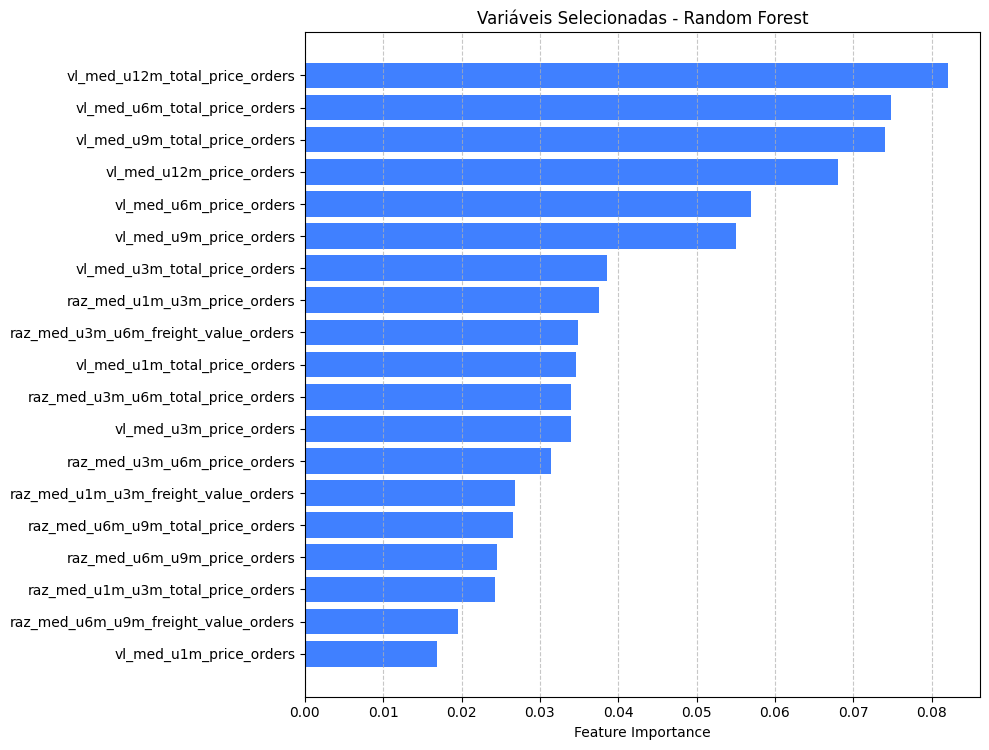

In [97]:
#Obtendo o feature importance
feature_importances = clf.feature_importances_
features = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': feature_importances
})

#Ordenar vars por importância
features = features.sort_values(by='Importance', ascending=False)

#Estabelecendo um ponto de corte
cutoff_maximp = 0.2

cutoff = cutoff_maximp * feature_importances.max()

# Selecionando vars acima do ponto de corte
selected_features = X_train_processed.columns[feature_importances > cutoff].tolist()
print('Número de features selecionadas: ', len(selected_features))

#Ordenar vars por importância
features = features.sort_values(by='Importance', ascending=True)

# Filtrar o DataFrame para apenas as features acima do corte
selected_features_df = features[features['Importance'] > cutoff]

# Ajusta o tamanho da figura com base no número de features selecionadas
plt.figure(figsize=(10, len(selected_features_df)*0.4))

# Plota as features selecionadas
plt.barh(selected_features_df['Feature'], selected_features_df['Importance'], color=(0.25, 0.5, 1))
plt.xlabel("Feature Importance")
plt.title("Variáveis Selecionadas - Random Forest")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [112]:
new_abt_treino, new_abt_teste, prep_objects = dataprep(X_train, X_test, y_train)
rf = RandomForestClassifier(
    random_state=0,
    class_weight='balanced',
    max_depth=3,
    min_samples_split=15,
    n_estimators=50
)

rf.fit(new_abt_treino, y_train)

feat_imp = pd.DataFrame({
    'Feature': new_abt_treino.columns,
    'Importance': rf.feature_importances_
})

features_rl = feat_imp.sort_values(by='Importance', ascending=False).head(20).Feature.tolist()

#features_rl = features_rl + ['y']
features_rl


['vl_med_u1m_total_price_orders',
 'vl_med_u1m_price_orders',
 'vl_med_u1m_freight_value_orders',
 'vl_qtd_u1m_price_orders',
 'vl_max_u1m_price_orders',
 'vl_max_u1m_total_price_orders',
 'vl_min_u3m_eficiencia_logistica_orders',
 'vl_med_u1m_fl_mesmo_estado_orders',
 'vl_max_u1m_freight_percentage_orders',
 'vl_min_u1m_total_price_orders',
 'vl_min_u1m_price_orders',
 'vl_min_u1m_freight_percentage_orders',
 'raz_med_u3m_u6m_freight_percentage_orders',
 'vl_max_u1m_freight_value_orders',
 'raz_med_u1m_u3m_dias_atraso_orders',
 'vl_std_u1m_freight_percentage_orders',
 'raz_med_u6m_u9m_freight_percentage_orders',
 'vl_std_u1m_freight_value_orders',
 'vl_std_u1m_price_orders',
 'raz_med_u1m_u3m_fl_atraso_orders']

In [106]:

import os
os.makedirs('../scripts/artifacts/', exist_ok=True)
# Salva as features selecionadas na pasta artifacts
with open('../scripts/artifacts/prd_selected_features_skl.pkl', 'wb') as f:
  pickle.dump(features_rl, f)

In [107]:
algoritmos = [
    DecisionTreeClassifier(criterion='gini', random_state=0, max_depth=7, min_samples_leaf=3),
    RandomForestClassifier(random_state=0, max_depth=7, min_samples_leaf=3),
    LGBMClassifier(random_state=0, max_depth=7, min_child_samples=3, n_jobs=-1, verbosity=-1,)
]

for algoritmo in algoritmos:

    nome_algoritmo = str(algoritmo)[:str(algoritmo).find("(")]
    # Treino do modelo
    algoritmo.fit(X_train_processed[features_rl],y_train)

    # Avaliar modelo
    metricas = calculate_metrics_models_classifier(nome_algoritmo,algoritmo, X_train_processed[features_rl], y_train, X_test_processed[features_rl], y_test)
    display(metricas)


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,DecisionTreeClassifier,Treino,0.925101,0.724060,0.849206,0.975419,0.950839,0.869895
1,DecisionTreeClassifier,Teste,0.749889,0.254011,0.250660,0.581631,0.163261,0.225306


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,RandomForestClassifier,Treino,0.938883,0.839024,0.758377,0.981892,0.963784,0.884496
1,RandomForestClassifier,Teste,0.812528,0.359477,0.145119,0.680215,0.360430,0.298422


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LGBMClassifier,Treino,0.989419,0.965669,0.967372,0.999254,0.998507,0.977847
1,LGBMClassifier,Teste,0.799645,0.330189,0.184697,0.614481,0.228962,0.226358


In [108]:
import optuna

OPTUNA_EARLY_STOPING = 10

class EarlyStoppingExceeded(optuna.exceptions.OptunaError):
    early_stop = OPTUNA_EARLY_STOPING
    early_stop_count = 0
    best_score = None

def early_stopping_opt(study, trial):
    if EarlyStoppingExceeded.best_score == None:
      EarlyStoppingExceeded.best_score = study.best_value

    if study.best_value < EarlyStoppingExceeded.best_score:
        EarlyStoppingExceeded.best_score = study.best_value
        EarlyStoppingExceeded.early_stop_count = 0
    else:
      if EarlyStoppingExceeded.early_stop_count > EarlyStoppingExceeded.early_stop:
            EarlyStoppingExceeded.early_stop_count = 0
            best_score = None
            raise EarlyStoppingExceeded()
      else:
            EarlyStoppingExceeded.early_stop_count=EarlyStoppingExceeded.early_stop_count+1
    #print(f'EarlyStop counter: {EarlyStoppingExceeded.early_stop_count}, Best score: {study.best_value} and {EarlyStoppingExceeded.best_score}')
    return

In [109]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fbeta_scorer = make_scorer(
        fbeta_score,
        beta=1.3,          # dá mais peso para recall
        pos_label=1      # classe FPD
)


# Objetiva do Optuna
def objective(trial):


    # 1. DEFINIÇÃO DO ESPAÇO DE BUSCA DE HIPERPARÂMETROS
    # Cada trial do Optuna irá sortear uma combinação diferente

    params = {

        # Hiperparâmetros básicos
        'n_estimators': trial.suggest_int('n_estimators', 5, 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        
        # Regularização
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        
        # Amostragem
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
        # Balanceamento de classes
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2, 10),
        
        # Tipo de boosting

        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 30),
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt']),
        'objective': 'binary',
        'verbosity': -1,
        'random_state': 42
    }


    model = LGBMClassifier(**params)


    # cross_val_score retorna uma lista com a métrica para cada fold
    scores = cross_val_score(model, X_train_processed[selected_features], y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    # Média dos AUCs
    return np.mean(scores)

# Estudo
study = optuna.create_study(direction="maximize",study_name="modelo")
study.add_trials(study.trials)
try:
    study.optimize(objective, n_trials=100, timeout=600, callbacks=[early_stopping_opt])

except EarlyStoppingExceeded:
    print(f'EarlyStopping Exceeded: No new best scores on iters {OPTUNA_EARLY_STOPING}')

print("Number of finished trials: {}".format(len(study.trials)))

print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))
     

[I 2026-05-23 14:27:15,403] A new study created in memory with name: modelo
[I 2026-05-23 14:27:16,719] Trial 0 finished with value: 0.9934083667899468 and parameters: {'n_estimators': 22, 'learning_rate': 0.04363249415214027, 'max_depth': 8, 'num_leaves': 91, 'reg_alpha': 0.023138034817220987, 'reg_lambda': 0.08172985255295062, 'subsample': 0.9694301837879609, 'colsample_bytree': 0.644283720663653, 'scale_pos_weight': 8.72306321903705, 'boosting_type': 'gbdt'}. Best is trial 0 with value: 0.9934083667899468.
[I 2026-05-23 14:27:17,874] Trial 1 finished with value: 0.9942940232280035 and parameters: {'n_estimators': 41, 'learning_rate': 0.05762404976055071, 'max_depth': 9, 'num_leaves': 68, 'reg_alpha': 0.8894162149573038, 'reg_lambda': 0.9484099560718692, 'subsample': 0.8168464593599334, 'colsample_bytree': 0.6951429868803254, 'scale_pos_weight': 3.5831367626111374, 'boosting_type': 'gbdt'}. Best is trial 1 with value: 0.9942940232280035.
[I 2026-05-23 14:27:18,738] Trial 2 finished w

EarlyStopping Exceeded: No new best scores on iters 10
Number of finished trials: 12
Best trial:
  Value: 0.9946348654297765
  Params: 
    n_estimators: 50
    learning_rate: 0.09220662206728943
    max_depth: 4
    num_leaves: 72
    reg_alpha: 0.38665491271585684
    reg_lambda: 0.8707409480298307
    subsample: 0.8522715549138233
    colsample_bytree: 0.6624073236534644
    scale_pos_weight: 3.9705113225611903
    boosting_type: gbdt


In [114]:
algoritmo = LGBMClassifier(**study.best_params, verbosity=-1)

nome_algoritmo = str(algoritmo)[:str(algoritmo).find("(")]
    # Treino do modelo
algoritmo.fit(X_train_processed[features_rl],y_train)

    # Avaliar modelo
metricas = calculate_metrics_models_classifier(nome_algoritmo,algoritmo, X_train_processed[features_rl], y_train, X_test_processed[features_rl], y_test)
display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LGBMClassifier,Treino,0.905750,0.627582,0.991182,0.981068,0.962135,0.888519
1,LGBMClassifier,Teste,0.743225,0.303748,0.406332,0.622878,0.245756,0.237592


In [115]:
import os
os.makedirs('../scripts/artifacts/', exist_ok=True)
with open('../scripts/artifacts/modelo_lgbm.pkl', 'wb') as file:
  pickle.dump(algoritmo, file)
     

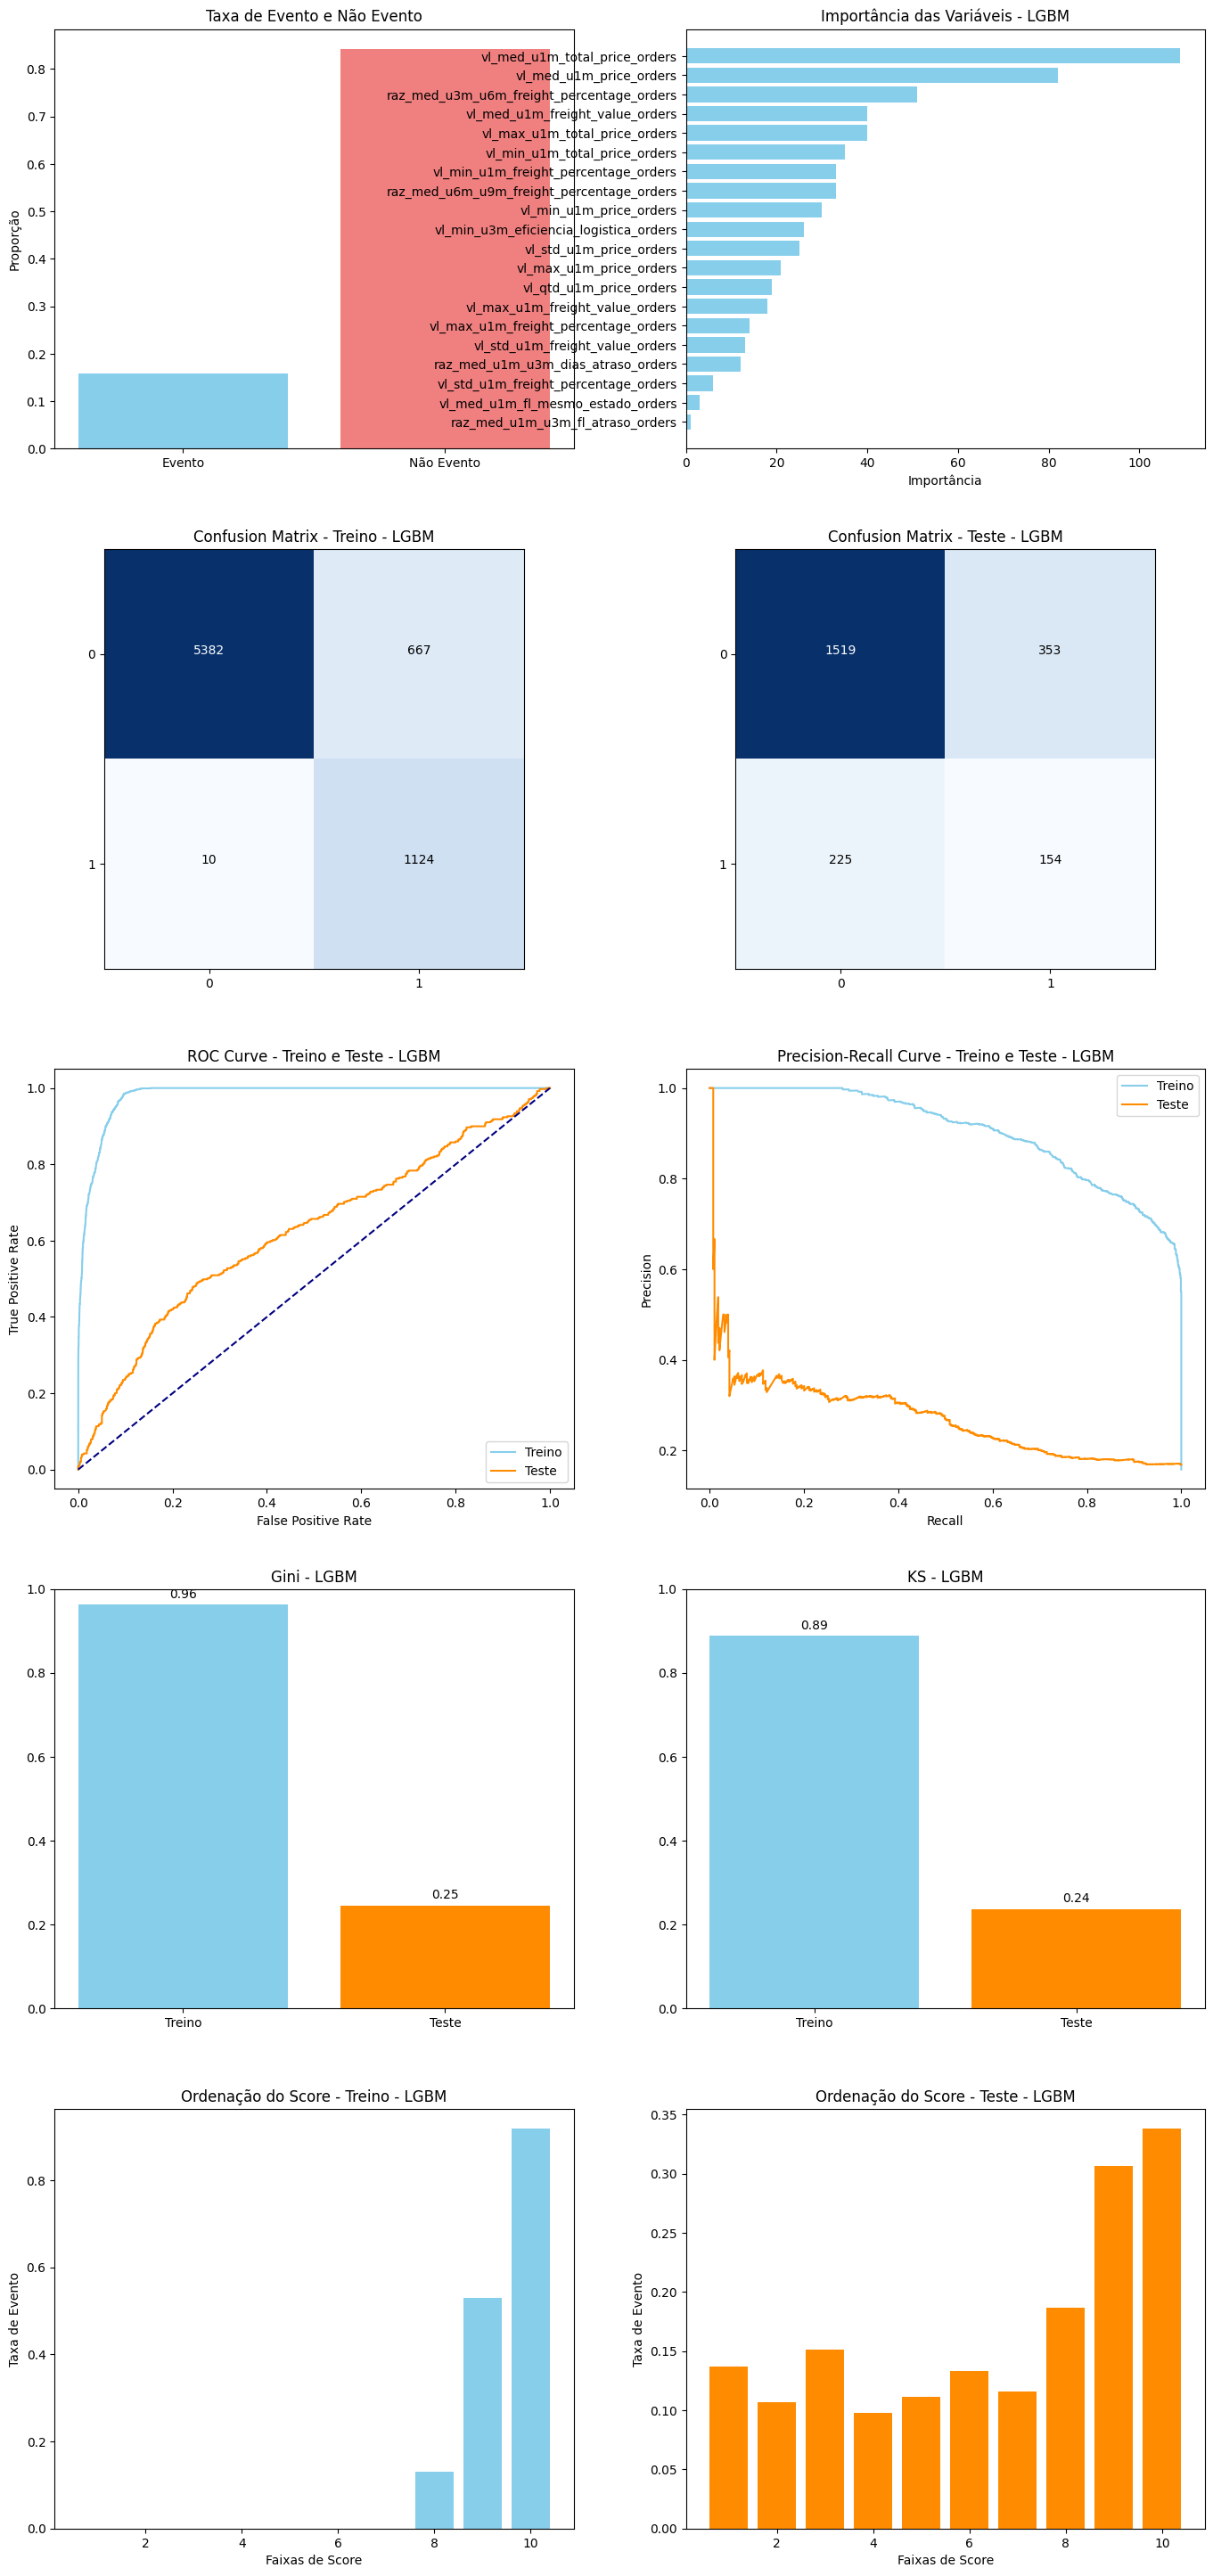

In [116]:
avaliar_modelo(X_train_processed[features_rl], y_train, X_test_processed[features_rl], y_test, algoritmo,nm_modelo='LGBM')

In [119]:
y_train.index = X_train_processed.index

bins = 10
tab = pd.concat([X_train_processed[features_rl],y_train],axis=1).copy()
tab['score'] = algoritmo.predict_proba(tab.drop(columns=['flag_sem_venda_2m']))[:,0]
tab['decile'] = pd.qcut(tab['score'], bins, labels=False)

# Criar tabela detalhada
table = tab.groupby('decile').agg(
    min_score=pd.NamedAgg(column='score', aggfunc='min'),
    max_score=pd.NamedAgg(column='score', aggfunc='max'),
    event_rate=pd.NamedAgg(column='flag_sem_venda_2m', aggfunc='mean'),
    volume=pd.NamedAgg(column='flag_sem_venda_2m', aggfunc='size'),
    qt_bads=pd.NamedAgg(column='flag_sem_venda_2m', aggfunc=lambda x: (x == 1).sum()),
    perc_total_bads=pd.NamedAgg(column='flag_sem_venda_2m', aggfunc=lambda x: (x == 1).sum()/tab[tab.flag_sem_venda_2m == 1].shape[0])
).reset_index()
table['min_score'] = 1000*table['min_score']
table['max_score'] = 1000*table['max_score']
table_train = table[['decile','event_rate','perc_total_bads', 'volume']]
table_train.rename(columns={'event_rate':'event_rate_train','perc_total_bads':'perc_total_bads_train', 'volume': 'volume_train'},inplace=True)
table_train

,decile,event_rate_train,perc_total_bads_train,volume_train
0,0,0.917942,0.582011,719
1,1,0.530641,0.335979,718
2,2,0.129526,0.082011,718
3,3,0.000000,0.000000,718
4,4,0.000000,0.000000,719
5,5,0.000000,0.000000,718
6,6,0.000000,0.000000,718
7,7,0.000000,0.000000,718
8,8,0.000000,0.000000,724
9,9,0.000000,0.000000,713


In [120]:
y_test.index = X_test_processed.index

bins = 10
tab = pd.concat([X_test_processed[features_rl],y_test],axis=1).copy()
tab['score'] = algoritmo.predict_proba(tab.drop(columns=['flag_sem_venda_2m']))[:,0]
tab['decile'] = pd.qcut(tab['score'], bins, labels=False)

# Criar tabela detalhada
table = tab.groupby('decile').agg(
    min_score=pd.NamedAgg(column='score', aggfunc='min'),
    max_score=pd.NamedAgg(column='score', aggfunc='max'),
    event_rate=pd.NamedAgg(column='flag_sem_venda_2m', aggfunc='mean'),
    volume=pd.NamedAgg(column='flag_sem_venda_2m', aggfunc='size'),
    qt_bads=pd.NamedAgg(column='flag_sem_venda_2m', aggfunc=lambda x: (x == 1).sum()),
    perc_total_bads=pd.NamedAgg(column='flag_sem_venda_2m', aggfunc=lambda x: (x == 1).sum()/tab[tab.flag_sem_venda_2m == 1].shape[0])
).reset_index()
table['min_score'] = 1000*table['min_score']
table['max_score'] = 1000*table['max_score']
table_test = table[['decile','event_rate','perc_total_bads', 'volume']]
table_test.rename(columns={'event_rate':'event_rate_test','perc_total_bads':'perc_total_bads_test', 'volume':'volume_test'},inplace=True)
table_test

,decile,event_rate_test,perc_total_bads_test,volume_test
0,0,0.336283,0.200528,226
1,1,0.306667,0.182058,225
2,2,0.186667,0.110818,225
3,3,0.115556,0.068602,225
4,4,0.133333,0.079156,225
5,5,0.111111,0.065963,225
6,6,0.097778,0.058047,225
7,7,0.155556,0.092348,225
8,8,0.102222,0.060686,225
9,9,0.137778,0.081794,225


In [121]:
summary = pd.merge(table_train,table_test,on='decile',how='inner')
summary

,decile,event_rate_train,perc_total_bads_train,volume_train,event_rate_test,perc_total_bads_test,volume_test
0,0,0.917942,0.582011,719,0.336283,0.200528,226
1,1,0.530641,0.335979,718,0.306667,0.182058,225
2,2,0.129526,0.082011,718,0.186667,0.110818,225
3,3,0.000000,0.000000,718,0.115556,0.068602,225
4,4,0.000000,0.000000,719,0.133333,0.079156,225
5,5,0.000000,0.000000,718,0.111111,0.065963,225
6,6,0.000000,0.000000,718,0.097778,0.058047,225
7,7,0.000000,0.000000,718,0.155556,0.092348,225
8,8,0.000000,0.000000,724,0.102222,0.060686,225
9,9,0.000000,0.000000,713,0.137778,0.081794,225


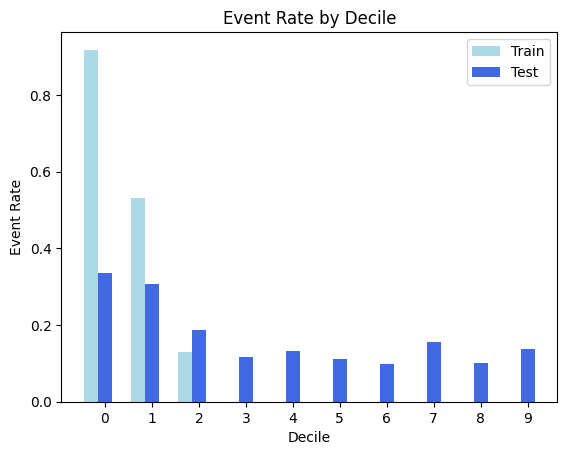

In [122]:
# Plotando o gráfico de barras para Event Rate por Decil
barWidth = 0.3
r1 = np.arange(len(summary))
r2 = [x + barWidth for x in r1]

plt.bar(r1, summary['event_rate_train'], color='lightblue', width=barWidth, label='Train')
plt.bar(r2, summary['event_rate_test'], color='royalblue', width=barWidth, label='Test')

plt.xlabel('Decile')
plt.ylabel('Event Rate')
plt.title('Event Rate by Decile')
plt.xticks([r + barWidth for r in range(len(summary))], summary['decile'])
plt.legend()
plt.show()